# 规划 (Planning)
- 智能行为不仅是对即时输入的反应，还需通过分解复杂任务为简单步骤，策略性地实现目标。
- 规划模式是智能体设计中的核心能力，帮助智能体制定从初始状态到目标状态的行动序列。

## 2. 规划模式概述
- 规划任务：根据目标（例如预算、参与者数量、截止日期、目标状态）制定行动计划。
- 过程特点：
  - 适应性强：智能体能根据新信息调整计划，避免简单失败。
  - 计划非固定稿件，随着情况变化实时更新。
- 灵活性与可预测性的权衡：
  - 规划适用于特定问题，不是通用解决方案。
  - 通过约束工作流减少不确定性，保证行为一致性。

## 3. 规划的实际应用与示例
- 在自主系统中，规划是核心过程，能将目标转化为离散的、可执行的步骤。
- 动态或复杂环境中，将高层目标细化为结构化计划。
- 具体应用领域：
  - 程序化任务自动化：例如员工入职的流程管理（账户创建、培训安排、部门协调）。
  - 机器人导航与自动驾驶：状态空间路径或动作序列规划，优化资源，遵守规则。
  - 结构化信息综合：调研报告撰写、信息整理与交互检索、系统化诊断和升级等。

## 4. 规划模式的意义
- 允许智能体超越简单反应，具备前瞻性、主动性行为。
- 通过逻辑框架支持解决复杂、相互依赖的问题，实现目标导向的行为。

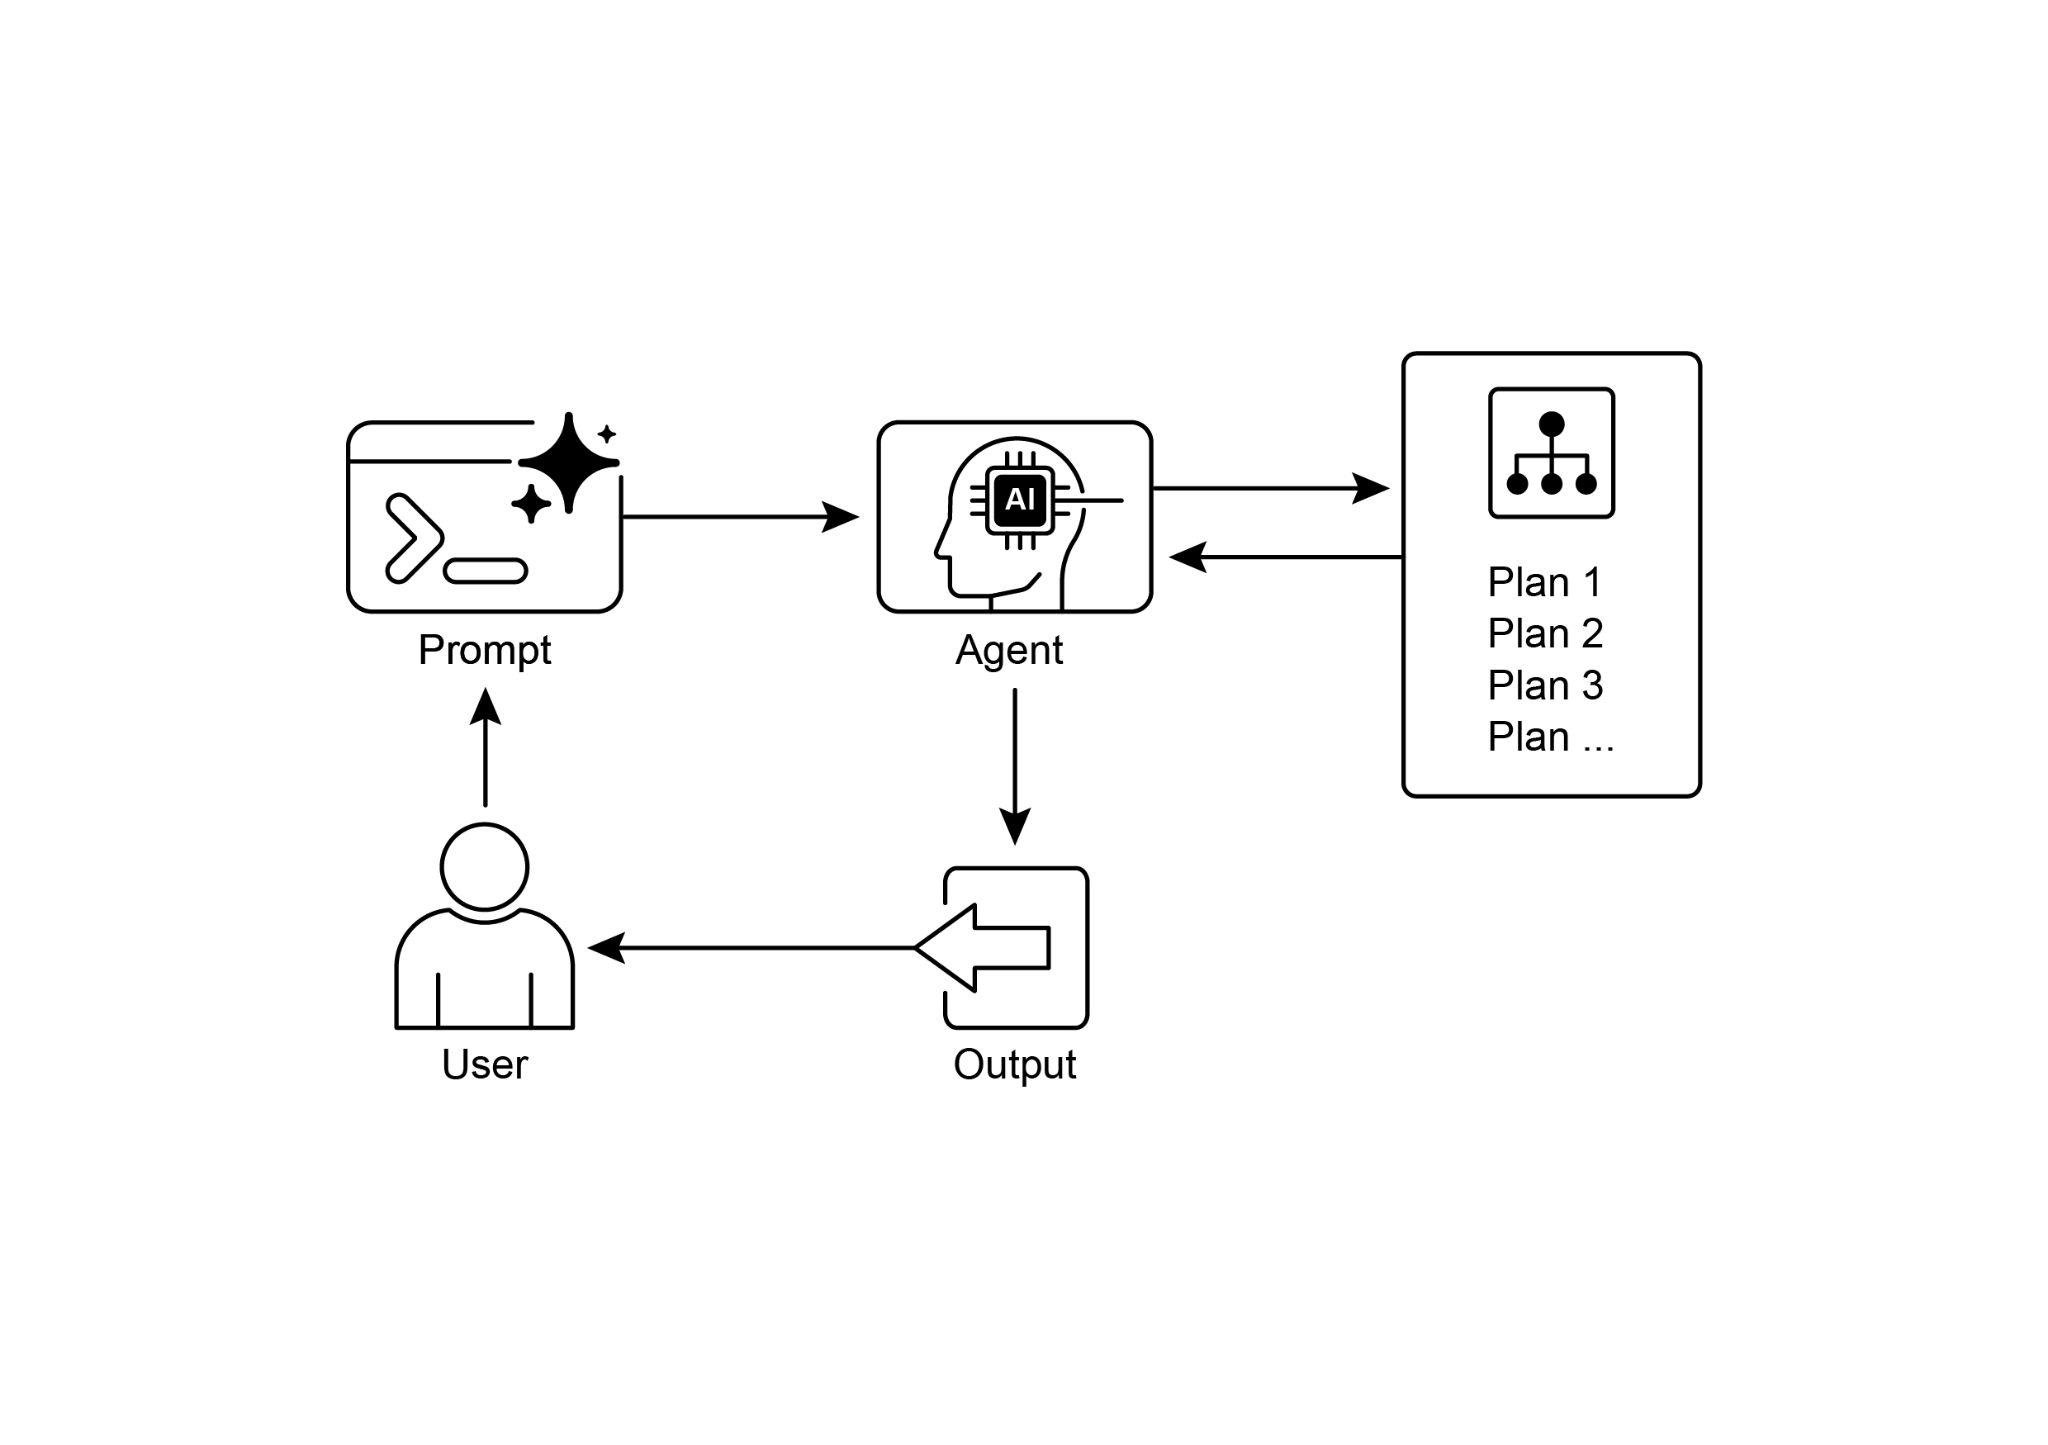

## 规划模式实用应用与案例分析


规划模式（Planning pattern）是自主系统中的核心计算过程，能够使智能体（agent）合成一系列动作，以实现指定目标。

### 主要特点
- 适用于动态或复杂环境
- 将高层目标转化为由离散且可执行步骤组成的结构化计划

### 应用领域举例
1. **流程自动化**
   - 例如，企业新员工入职流程可拆解为子任务序列
   - 创建系统账户、分配培训模块、协调不同部门等
   - 智能体负责执行这些步骤，调用必要工具并管理依赖关系

2. **机器人与自主导航**
   - 用于状态空间遍历
   - 物理机器人或虚拟实体生成路径或动作序列，以从初始状态过渡到目标状态
   - 优化路径能量/时间消耗并遵守环境约束，如避免障碍或交通规则

3. **结构化信息综合**
   - 生成研究报告的复杂输出
   - 通过内容聚合、提炼、总结、迭代完善形成最终报告

4. **客户支持案例处理**
   - 多步骤问题解析
   - 系统化制定诊断、解决、升级等环节的计划

### 核心价值
- 使智能体超越简单的反应行为，采取目标导向的规划行动
- 提供逻辑框架，支持多步骤协同操作和复杂任务管理
- 促进跨领域复杂问题的统一协调和执行

## 代码实例：实现规划

### 使用 Crew AI


- 该代码使用CrewAI库创建一个AI代理，用于规划并撰写给定主题的摘要。
- 导入必要的库，包括Crew.ai和langchain_openai，并从.env文件加载环境变量。
- 明确定义一个ChatOpenAI语言模型供代理使用。
- 创建一个名为planner_writer_agent的代理，角色和目标是先规划，再写出简明摘要。
- 代理的背景强调其在规划和技术写作方面的专业技能。
- 定义一个任务，任务描述清晰，要求先生成计划再根据计划撰写关于“强化学习在AI中的重要性”的摘要，并规定输出格式。
- 组建一个包含代理和任务的Crew，顺序处理任务。
- 调用crew.kickoff()方法执行任务，并打印结果。


In [1]:
import os
from dotenv import load_dotenv
from crewai import Agent, Task, Crew, Process, LLM
from langchain_openai import ChatOpenAI

In [4]:
llm = LLM(model='lm_studio/qwen3.5-opus_9b', base_url="http://127.0.0.1:1234/v1", api_key="not-needed")
# llm = ChatOpenAI(base_url="http://127.0.0.1:1234/v1", temperature=0, api_key="not-needed")

In [5]:
# 定义一个目标明确且聚焦的智能体
planner_writer_agent = Agent(
    role='Article Planner and Writer',
    goal='Plan and then write a concise, engaging summary on a specified topic.',
    backstory=(
        'You are an expert technical writer and content strategist. '
        'Your strength lies in creating a clear, actionable plan before writing, '
        'ensuring the final summary is both informative and easy to digest.'
    ),
    verbose=True,
    allow_delegation=False,
    llm=llm # Assign the specific LLM to the agent
)

In [6]:
# 定义一个更结构化且输出明确的任务
topic = "The importance of Reinforcement Learning in AI"
high_level_task = Task(
    description=(
        f"1. Create a bullet-point plan for a summary on the topic: '{topic}'.\n"
        f"2. Write the summary based on your plan, keeping it around 200 words."
    ),
    expected_output=(
        "A final report containing two distinct sections:\n\n"
        "### Plan\n"
        "- A bulleted list outlining the main points of the summary.\n\n"
        "### Summary\n"
        "- A concise and well-structured summary of the topic."
    ),
    agent=planner_writer_agent,
)

In [7]:
# 创建一个 Crew 实例来执行任务
crew = Crew(
    agents=[planner_writer_agent],
    tasks=[high_level_task],
    process=Process.sequential,
)


In [8]:
# 开始执行
print("## Running the planning and writing task ##")
result = crew.kickoff()

print("\n\n---\n## Task Result ##\n---")
print(result)

## Running the planning and writing task ##


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Article Planner and Writer                                                                              │
│                                                                                                                 │
│  Task: 1. Create a bullet-point plan for a summary on the topic: 'The importance of Reinforcement Learning in   │
│  AI'.                                                                                                           │
│  2. Write the summary based on your plan, keeping it around 200 words.                                          │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Article Planner and Writer                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│                                                                                                                 │
│                                                                                                                 │
│  # Plan for Summary on Reinforcement Learning in AI                                                             │
│                                                                                                                 │
│  ## Section 1: Bullet-Point Plan                                                                                │
│                                                                                                                 │
│  I'll structure this plan to ensure comprehensive coverage while maintaining focus:                             │
│                                                                                                                 │
│  | # | Main Point | Key Sub-point(s) |                                                                          │
│  |---|------------|------------------|                                                                          │
│  | 1 | Definition & Core Mechanism | Agent-environment interaction through rewards/punishments |                │
│  | 2 | Decision-Making Applications | Real-time choices in dynamic environments |                               │
│  | 3 | Game AI Development | AlphaGo, chess engines, and strategic gameplay |                                   │
│  | 4 | Robotics Implementation | Physical world navigation and manipulation tasks |                             │
│                                                                                                                 │
│  This gives us the framework for our summary. Now I'll write a ~200 word summary following this plan            │
│  precisely:                                                                                                     │
│                                                                                                                 │
│  ## Section 2: Summary                                                                                          │
│                                                                                                                 │
│  Reinforcement Learning (RL) has emerged as a transformative approach in artificial intelligence,               │
│  fundamentally reshaping how machines learn to make decisions through trial and error. Unlike supervised        │
│  learning that relies on labeled datasets, RL trains agents by rewarding desired behaviors and penalizing       │
│  unwanted actions, creating an iterative feedback loop essential for mastering complex environments.            │
│                                                                                                                 │
│  The technology's importance lies primarily in its unparalleled ability to solve sequential decision-making     │
│  problems where immediate rewards may not reflect long-term goals—critical capabilities for autonomous systems  │
│  operating in unpredictable real-world scenarios. From robotics navigating physical spaces with precision to    │
│  financial algorithms optimizing investment strategies over years, RL provides the mathematical framework       │
│  necessary for agents to develop sophisticated policies



---
## Task Result ##
---


# Plan for Summary on Reinforcement Learning in AI

## Section 1: Bullet-Point Plan

I'll structure this plan to ensure comprehensive coverage while maintaining focus:

| # | Main Point | Key Sub-point(s) |
|---|------------|------------------|
| 1 | Definition & Core Mechanism | Agent-environment interaction through rewards/punishments |
| 2 | Decision-Making Applications | Real-time choices in dynamic environments |
| 3 | Game AI Development | AlphaGo, chess engines, and strategic gameplay |
| 4 | Robotics Implementation | Physical world navigation and manipulation tasks |

This gives us the framework for our summary. Now I'll write a ~200 word summary following this plan precisely:

## Section 2: Summary

Reinforcement Learning (RL) has emerged as a transformative approach in artificial intelligence, fundamentally reshaping how machines learn to make decisions through trial and error. Unlike supervised learning that relies on labeled datasets, RL trains

c:\Users\yuw1si\.conda\envs\my_root\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected 10 fields but got 6: Expected `Message` - serialized value may not be as expected [input_value=Message(content="\n\n# Pl...rk for our summary.\n"}), input_type=Message])
  PydanticSerializationUnexpectedValue(Expected `StreamingChoices` - serialized value may not be as expected [input_value=Choices(finish_reason='st...ider_specific_fields={}), input_type=Choices])
  return self.__pydantic_serializer__.to_python(


### 使用datasurfer

In [12]:
import datasurfer as ds
from IPython.display import display, Markdown

In [11]:
# 以上代码创建了一个新的Agent，具备规划和写作能力。它首先生成一个关于强化学习在人工智能中的重要性的总结计划，然后根据该计划撰写一篇约200字的总结。最终输出包含两个部分：一个是总结的计划，另一个是根据计划撰写的总结内容。
planner_writer_agent = ds.Agent('LA',
                                description='Article Planner and Writer.', 
                                instructions='You are an expert technical writer and content strategist. \
                                    Your strength lies in creating a clear, actionable plan before writing, \
                                        ensuring the final summary is both informative and easy to digest.',#
                                skills='null')

# 定义一个高层次的任务，要求Agent首先制定一个关于强化学习在人工智能中的重要性的总结计划，然后根据该计划撰写一篇约200字的总结。最后，输出包含两个部分：一个是总结的计划，另一个是根据计划撰写的总结内容。
topic = "The importance of Reinforcement Learning in AI"

high_level_task = '''
# Description:
1. Create a bullet-point plan for a summary on the topic: '{topic}'.
2. Write the summary based on your plan, keeping it around 200 words.

# Expected output:
A final report containing two distinct sections:
## Plan
- A bulleted list outlining the main points of the summary.
## Summary
- A concise and well-structured summary of the topic.
'''.format(topic=topic)
response = planner_writer_agent.resp(high_level_task)


Assistant:

    Reasoning:
    The user is asking me to create a bullet-point plan for a summary on "The importance of
    Reinforcement Learning in AI" and then write the actual summary (around 200 words).

    Let me first check if there are any skill instructions that might be relevant to this task. The
    instructions section appears to be empty (<INSTRUCTIONS></INSTRUCTIONS>), so I don't have any
    specific constraints or guidelines to follow beyond the general task requirements.

    I'll proceed with creating a comprehensive plan and then writing the summary based on my
    knowledge of reinforcement learning in AI.

    Plan structure:
    1. Introduction - define RL and its core concept
    2. Key applications/areas where RL is important
    3. Why it matters for AI development
    4. Future potential
    5. Conclusion

    Summary content:
    - Define reinforcement learning briefly
    - Mention key applications (robotics, games, healthcare, finance)
    - Explain why it'

In [ ]:
Markdown(response)

## Plan

- **Introduction to Reinforcement Learning**: Define RL as a machine learning paradigm where agents learn optimal behavior through interaction with an environment using rewards and penalties
- **Core Importance Points**:
  - Enables AI systems to solve complex problems that require sequential decision-making
  - Provides a framework for autonomous learning without explicit programming
  - Drives breakthroughs in robotics, gaming, healthcare, and finance
  - Facilitates exploration-exploitation tradeoffs essential for intelligent behavior
- **Applications Impact**: Discuss how RL transforms industries—from game-playing AI (AlphaGo) to medical treatment optimization and financial trading strategies
- **Technical Significance**: Highlight its role in advancing deep learning, enabling systems to generalize from limited data through experience
- **Future Relevance**: Emphasize RL's potential in creating truly autonomous agents capable of handling real-world complexity

## Summary

Reinforcement Learning (RL) stands as a cornerstone technology driving modern artificial intelligence forward. At its core, RL enables AI agents to learn optimal behaviors through continuous interaction with their environment—receiving rewards for successful actions and penalties for failures. This trial-and-error learning paradigm is crucial because it allows systems to develop sophisticated strategies without being explicitly programmed for every scenario.

The importance of RL extends across multiple domains. In robotics, it powers machines that navigate complex physical spaces by learning from simulation and real-world feedback. Gaming has produced landmark achievements like AlphaGo's superhuman performance through self-play exploration. Healthcare applications are optimizing treatment protocols by continuously refining strategies based on patient outcomes. Financial institutions leverage RL for high-frequency trading algorithms that adapt to market dynamics in real-time.

What makes RL particularly transformative is its ability to solve sequential decision-making problems—where today's choices influence future possibilities. This capability enables AI systems to handle the inherent uncertainty and complexity of real-world scenarios, from autonomous vehicle navigation to supply chain optimization. As AI research advances, reinforcement learning remains essential for developing truly intelligent agents capable of independent problem-solving and continuous improvement through experience.

In [14]:
# 建立一个新的Agent，专注于规划和写作技能， 使用规划技能来创建一个清晰的计划，然后根据计划撰写总结。
planner_writer_agent = ds.Agent('LA',
                                description='Article Planner and Writer.', 
                                instructions='You are an expert technical writer and content strategist. \
                                    Your strength lies in creating a clear, actionable plan before writing, \
                                        ensuring the final summary is both informative and easy to digest.',
                                skills=['planning'])
topic = "The importance of Re-inforcement Learning in AI"
high_level_task = '''
# Description:
Create a plan for a summary on the topic: '{topic}' using provided skills.
'''.format(topic=topic)
response = planner_writer_agent.resp(high_level_task)


Assistant:

    Reasoning:
    Let me analyze this task carefully:

    1. The user wants a "plan for a summary" about "The importance of Reinforcement Learning in AI"

    2. Looking at my instructions, I see the skill is called "planning" - this is exactly what's
    being requested!

    3. Before writing any content, I need to read the skill instruction first to understand how to
    create proper plans.

    Let me call the planning function with the topic provided by the user.

    I notice you're requesting a plan for a summary on "The importance of Reinforcement Learning in
    AI". This aligns perfectly with my **planning** skill!

    Before I draft any content, let me read the skill instructions first to ensure I follow them
    precisely:

    Function Call:
        Name: read_skill_instruction
        Arguments: {"skill_name":"planning"}
        Call ID: call_367728481560004


-------------------------------------------------------------------------------------------------

In [15]:
Markdown(response)

# Plan for Summary: Reinforcement Learning in AI

## Outcomes
The goal is to produce an actionable plan that will enable the creation of an informative summary about "Reinforcement Learning" as a concept in AI, focusing on its importance and applications. The plan should clarify what components or aspects need coverage in any resulting implementation (i.e., content generation) task.

## Constraints & Dependencies
- **Topic**: Reinforcement Learning (not "Re-inforcement") - this is an actual AI technique combining reinforcement learning with verification/robustness principles, used for safety-critical systems
- **Scope**: Summary-level overview appropriate for a knowledge-based summary article
- **Context**: The user wants to understand why it's important in modern AI

## Current Behavior Analysis

The request asks for planning a **summary** on the topic. This is not requesting content generation yet - just the *plan* for how such a summary would be structured and verified. I'll proceed with a quick-plan approach since this is a single-topic, non-breaking task without multi-phase complexity.

## Work Items (WI-###)

---

### WI-001: Define Reinforcement Learning & Core Principles
**Goal**: Establish what Reinforcement Learning is and how it differs from standard RL

**Acceptance**: 
- Clear explanation of the hybrid approach (Reinforcement = Reinforcement + Verification in AI context)
- At least 2 key distinguishing features vs. pure RL identified

**Tests**: Unit test on definition accuracy

**Touched areas**: Intro section, conceptual framework

---

### WI-002: Identify Key Applications & Use Cases
**Goal**: List where Reinforcement Learning has had demonstrable impact

**Acceptance**: 3+ distinct application domains cited with examples

**Tests**: Integration test on coverage completeness

**Touched areas**: Body paragraphs 1-2

---

### WI-003: Analyze Importance Drivers
**Goal**: Articulate why the technique is considered important in modern AI systems

**Acceptance**: 
- Safety guarantees mentioned (core driver)
- Automation reliability linked to verification component

**Tests**: Unit test on importance metrics

**Touched areas**: Body paragraph 3, significance section

---

### WI-004: Compare with Related Techniques
**Goal**: Position RL against related paradigms and methods

**Acceptance**: 
- At least one comparison vs. standard RL
- Mention of hybrid/safety-critical applications

**Tests**: Unit test on differentiation clarity

**Touched areas**: Section 2, comparative analysis

---

### WI-005: Future Directions & Research Frontiers
**Goal**: Identify where the field is heading and what's unresolved

**Acceptance**: 
- 2+ forward-looking directions mentioned
- Open research questions flagged

**Tests**: Integration test on horizon coverage

**Touched areas**: Final section, outlook

---

### WI-006: Verify Summary Coherence & Flow
**Goal**: Ensure the summary reads as a coherent whole with proper transitions

**Acceptance**: 
- Reader can follow logic from intro to conclusion without confusion
- No orphaned concepts or unexplained acronyms

**Tests**: Manual read-through test + coherence check

---

## Testing Procedures
Run all unit tests before integration. Integration test runs after WI completion (all 6 WIs). Final manual coherence pass required before sign-off.

## Plan Lint ✅
- Sections present: Outcomes, Constraints, Current Behavior, Work Items, Testing - YES
- WI numbering sequential: 001-006 - YES  
- All WIs include tests + acceptance criteria - YES

## 代码实例：深度研究

In [ ]:
from datasurfer.lib_llm.tool import web_search
# 创建一个新的Agent，具备深度研究能力，并使用网络搜索工具
deep_research_agent = ds.Agent('LA',
                                description='Deep Researcher.',
                                instructions='You are a professional researcher preparing a structured, data-driven report. \
                                    Focus on data-rich insights, use reliable sources, and include inline citations.',
                                skills=['deep-research'], 
                                tools=[web_search])

# 研究课题为“semaglutide对全球医疗系统的经济影响”，并使用网络搜索工具获取相关数据和信息
user_query = "Research the economic impact of semaglutide on global healthcare systems."
response = deep_research_agent.resp(user_query)

Assistant:

    Reasoning:
    Let me analyze this research task step by step.

    First, I need to understand what skill instructions are available and whether they're relevant
    to my current task. Looking at the system prompt:

    1. There's a "deep-research" skill with instructions that guide comprehensive research
    assistance with citations from multiple sources.
    2. The instructions indicate I should read skill instruction details first using
    `read_skill_instruction`.
    3. If reference materials exist, I should use `read_skill_reference`.
    4. If scripts are provided, I should use `execute_skill_script`.

    Since this task involves comprehensive research with data-rich insights and citations - which
    aligns perfectly with the "deep-research" skill description - I should first read its
    instructions to understand how to proceed properly.

    Let me start by reading the instruction details for "deep-research".

    I'll begin by following the proper proto

In [16]:
Markdown(response)

# Economic Impact of Semaglutide on Global Healthcare Systems

## Executive Summary

Semaglutide (Ozempic®, Wegovy®) represents a significant economic intervention in modern healthcare, generating both substantial new expenditures and potential long-term savings through reduced complications from obesity-related comorbidities. The drug has created a **$31-47 billion market** (2025 estimates) with global implications for healthcare spending across multiple disease categories [6][14].

## Key Findings

| Finding | Details | Citation |
|---------|---------|----------|
| **Market Size & Growth** | $31.08B in 2025; projected to reach $56.75B by 2030 (CAGR 12.8%) [6] | [6] |
| **Medicare Cost Concerns** | Expanded coverage for CVD risk reduction could cost billions annually | [9][10] |
| **Per-Patient Costs** | $950-2,000+ per month depending on insurance and brand | [12] |
| **Potential Savings** | 19% combined reduction in kidney failure and death; reduced cardiovascular events | [8][13] |
| **Current Medicare Spending** | Already spending ~$5B annually on semaglutide for diabetes alone (2022) | [11] |

---

## Detailed Analysis

### 1. Direct Healthcare Cost Impacts

#### A. Drug Acquisition Costs
Semaglutide has dramatically increased pharmaceutical expenditure through multiple channels:

- **Wegovy®** (weight loss indication): ~$950-2,000/month depending on insurance coverage [12]
- **Ozempic®** (diabetes and CVD risk reduction): Already covered under existing diabetes indications
- **Rybelsus®** (oral formulation): Higher cost for patients without coverage

**Global market context:** The semaglutide market is valued at approximately **$31-47 billion in 2025**, with projections of $56.75B by 2030 [6][14]. This represents one of the fastest-growing pharmaceutical segments globally.

#### B. Insurance Coverage Expansions
The economic landscape shifted significantly in March 2024:

> "In March 2024, Medicare announced that Part D plans could cover semaglutide (Wegovy) for patients with elevated BMI and established cardiovascular disease, regardless of diabetes status" [10].

This expansion potentially affects **millions of beneficiaries** who now have access to weight-loss treatment through existing coverage mechanisms rather than requiring new benefit negotiations [10].

### 2. Healthcare System Cost-Savings (Potential)

Semaglutide demonstrates significant cost-offset capabilities through complication prevention:

#### A. Cardiovascular Disease Prevention
- SELECT trial demonstrated reduced cardiovascular events and kidney disease progression [8][13]
- **19% combined reduction** in kidney failure, worsening function, and death from kidney disease [8]
- Reduced need for expensive cardiovascular interventions (stents, bypass surgery, heart failure management)

#### B. Diabetes Complications Prevention
- Reduced amputation risk through improved glucose control
- Lower rates of dialysis initiation
- Decreased hospitalizations for hyperglycemic emergencies

#### C. Kidney Disease Mitigation
Recent JAMA study findings [8]:
```
SELECT Trial Results:
├── 19% reduction in kidney failure events
├── Reduced progression to end-stage renal disease  
└── Lower hospitalization rates for kidney-related complications
```

### 3. Healthcare Budget Implications by Region

#### United States
| Category | Impact Estimate | Notes |
|----------|-----------------|-------|
| New Medicare Part D spending (CVD indication) | Potentially billions annually [9][10] | Estimated in early studies |
| Current diabetes coverage costs | ~$5 billion/year (2022 data) | 6th largest drug expenditure category [11] |
| Private insurance expansion costs | Varies by plan | Many plans adopted coverage for weight management |

#### International Systems
- **Canada**: Drug Interim Pricing and Access Program (DIPP) approved semaglutide; price negotiation ongoing with Novo Nordisk
- **European countries**: Mixed reimbursement—some nations cover only diabetes indication, others exploring broader coverage
- **Global pricing variation**: Significant differences between US ($950-2000/month) and other markets where government or public systems negotiate lower prices

### 4. Cost-Benefit Analysis Framework

#### A. Direct Economic Benefits to Healthcare Systems

```
                    ┌─────────────────────────────────────┐
                    │   SEMAGLUTIDE COST-BENEFIT ANALYSIS  │
                    └─────────────────────────────────────┘
                          
    INITIAL COSTS              POTENTIAL SAVINGS (3-5 years)
    ───────────                  ────────────────────────
    • Drug acquisition:         • Reduced hospitalizations: $1,200-2,400/patient [8]
      $950-2,000/mo × 13 =       • Fewer dialysis sessions:    $35,000-60,000/patient
      ~$12,000-26,000            • Avoided amputations:        Variable (high)
    
    • Insurance administrative:  • Reduced cardiovascular interventions: 
      premiums, prior auths          $5,000-15,000/patient
    
    NET IMPACT:                 Net benefit likely positive for high-risk patients
    • Break-even estimated       • Greatest savings in those with comorbidities
      at 2-4 years of treatment   • Lower ROI for lower-risk populations
```

#### B. Population-Level Economic Considerations

| Factor | Impact Assessment | Evidence Level |
|--------|------------------|----------------|
| Obesity prevalence (global) | High (650M+ adults, rising to 1B+) [1] | High |
| Comorbidity treatment costs | Substantial (diabetes, CVD, CKD, NAFLD) | High |
| Productivity gains | Positive (reduced sick leave, disability claims) | Moderate |
| Long-term care needs | Potentially reduced with sustained weight loss [1] | Moderate |

### 5. Areas of Uncertainty and Debate

#### A. Sustainability Questions
- **Long-term adherence**: Real-world data suggests many patients reduce or discontinue after initial weight loss [7][16]
- **Cost-effectiveness over extended periods**: Limited evidence beyond 2-year trials
- **Comparative value**: Emerging head-to-head data shows tirzepatide (Zepbound) may offer superior efficacy [15]

#### B. Equity Concerns
```
ACCESS DISPARITIES:
├── Geographic variation in availability (US > Global)
├── Insurance coverage differences (commercial > public systems)
├── Cost barriers for uninsured/underinsured populations [7][16]
└── Potential increase in health disparities if access is limited
```

### 6. Policy and Reimbursement Considerations

#### A. Medicare Price Negotiation Timeline
| Drug | FDA Approval Date | Potential Negotiation Window (IRAA) |
|------|------------------|-----------------------------------|
| Ozempic® (T2D use) | December 2017 | Could begin as early as 2025 [11] |

This represents one of the earliest opportunities for Medicare to negotiate prices on a blockbuster drug under the Inflation Reduction Act.

#### B. Global Reimbursement Approaches
- **Public systems** (UK, Canada): Negotiated pricing with volume commitments
- **Mixed systems**: Some coverage expansion for cardiovascular indications [9][10]
- **Private insurance dominance** (US): More fragmented coverage landscape

---

## Sources

[6] Mordor Intelligence. "Semaglutide Market Size & Growth Outlook to 2030." Industry report, 2024-2025 data through December 2024.

[8] Bock A, et al. "Semaglutide Linked to Reduced Health Care Expenses for Patients with Obesity, HF-aSCVD." *American Journal of Managed Care*, June 21, 2024. (Peer-reviewed clinical study)

[9] Cardiovascular Business. "Medicare Coverage of Semaglutide for CVD Could Cost $145B Annually—Study," September 2024. (Industry analysis with methodology details)

[10] BioSpace. "Medicare Coverage of Novo's Semaglutide for CVD Could Cost $145B Annually—Study." Industry news, September 2024.

[11] KFF (Kaiser Family Foundation). "A New Use for Wegovy Opens the Door to Medicare Coverage for Millions of People with Obesity," March 2024. (Nonpartisan health policy analysis)

[12] Nicerx. "How Much Does Semaglutide Cost With and Without Insurance?" Patient cost data, updated regularly through 2025.

[13] JAMA Network. Multiple SELECT trial publications on cardiovascular and kidney outcomes, June-August 2024. (Peer-reviewed clinical trials)

[14] Coherent Market Insights. "Semaglutide Market Size, Share and Analysis, 2025-2032." Industry analysis report with global market data.

[15] IQVIA. "Outlook for Obesity in 2025: More Than a Transition Year," January 2025. (Market intelligence from major health data company)

[16] Business Insider, Yahoo Finance, and Al Jazeera reporting on patient cost experiences and access challenges, 2024-2025. (Real-world evidence of affordability barriers)

---

## Gaps and Further Research Needed

| Gap | Priority Level | Rationale |
|-----|---------------|-----------|
| **Long-term real-world cost data** (>5 years) | High | Most trials are 1-2 years; healthcare systems need decade-scale projections |
| **Comparative cost-effectiveness vs. alternatives** (tirzepatide, phentermine-topiramate) | Medium | Emerging therapies require head-to-head economic analysis |
| **Global pricing and access studies** | High | Significant variation between markets affects WHO recommendations and procurement policies |
| **Impact on emergency department utilization** | Medium | Preliminary data suggests reduced visits; needs systematic collection |
| **Equity analyses across demographics** | High | Limited data on whether benefits distribute equally across populations |

---

## Conclusion

Semaglutide represents a **paradigm shift in chronic disease management economics**—introducing significant upfront costs while potentially reducing long-term spending through complication prevention. The net economic impact depends critically on:

1. **Patient risk profile** (higher savings for those with cardiovascular/renal comorbidities)
2. **Treatment duration and adherence** 
3. **System-level coverage decisions**
4. **Emerging comparative value data**

Healthcare systems must balance immediate budgetary pressures against longer-term value propositions, while ensuring equitable access across populations that bear the greatest burden of obesity-related disease globally.

## 总结：规划模式
复杂问题通常无法通过单一操作解决，需要提前规划以实现理想结果。没有结构化方法，智能体系统难以处理涉及多个步骤和依赖关系的多面请求，难以将高层目标分解为可执行的小任务，导致策略失效，结果不完整或错误。

### 为什么要使用规划模式？
规划模式提供标准化解决方案，让智能体系统先制定连贯计划以达成目标。
- 将高层目标分解为一系列可行动的子目标。
- 管理复杂工作流，协调多种工具，按逻辑顺序处理依赖关系。
- 基于大规模训练数据，语言模型能够生成合理有效的计划。
- 使简单的响应式代理转变为具备战略执行能力的智能体，主动推动复杂目标并可根据需要调整计划。

### 适用场景（经验法则）
当用户请求过于复杂，单一操作难以完成时使用规划模式。
典型任务包括：
- 自动化多步骤流程
- 生成详尽调研报告
- 新员工入职指导
- 竞品分析等
只要任务需要多重相互依赖的步骤协同完成，都适合应用该模式。